# Analiza wynikow: LUNAR w detekcji anomalii — wplyw rozmiaru proby tuningu, zespoly, koszt vs zysk

Notebook w stylu akademickim (czarno-szara paleta, brak siatki, eksport PDF) generujacy
**7 wykresow i 2 tabele** do pracy dyplomowej, zgodnie ze specyfikacja:

1. Sekcja 1 — wplyw rozmiaru proby optymalizacyjnej (Wykres 1 + Tabela 1)
2. Sekcja 2 — modele pojedyncze vs zespoly (Wykres 2 + Tabela 2)
3. Sekcja 3 — wartosc dodana LUNAR w zespolach (Wykres 3 delta + Wykres 4 heatmapa)
4. Sekcja 4 — kompromis koszt/zysk (Wykres 5 inference, Wykres 6 training)
5. Sekcja 5 — krzywe Precision-Recall (Wykres 7)
6. Sekcja 6 — propozycje wlasne: test istotnosci statystycznej + wskaznik cost-benefit

**Run 1/2/3** = rosnacy rozmiar proby danych uzytej do tuningu hiperparametrow (mala/srednia/duza).
Ta informacja nie jest zapisana jako osobna kolumna w `all_results_flat.csv` — funkcja
`add_run_index()` nizej wyprowadza ja automatycznie (patrz komentarz w kodzie).

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats
from IPython.display import display

RESULTS_DIR = Path("../results")
AGG_DIR = RESULTS_DIR / "aggregation"
FIG_DIR = AGG_DIR / "notebook_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'figure.titlesize': 14, 'figure.dpi': 110,
})
PALETTE = "Set2"
MARKERS = ["o", "s", "^", "D", "v"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False,
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "xtick.color": "black",
    "ytick.color": "black",
    "figure.dpi": 110,
    "savefig.dpi": 300,
})
sns.set_style("white")

SINGLE_MODELS = ["LOF", "IsolationForest", "OneClassSVM", "LUNAR"]
ENSEMBLE_MODELS = ["Ensemble_with_LUNAR", "Ensemble_without_LUNAR", "LUNAR_Self_Ensemble"]
METRIC_COLS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1"]


def save_fig(fig, name):
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Zapisano: {pdf_path.name} , {png_path.name}")
    return pdf_path, png_path


def categorize(model_type):
    if model_type in SINGLE_MODELS:
        return "Single Models"
    if model_type in ENSEMBLE_MODELS:
        return "Ensembles"
    return None


def add_run_index(df, group_cols=("dataset_name", "model_type", "fusion_strategy")):
    df = df.copy()
    group_cols = [c for c in group_cols if c in df.columns]

    candidate_cols = [c for c in df.columns if c.lower() in
                       ("hyperparameters.note", "hyperparameters.run",
                        "hyperparameters.tuning_run", "hyperparameters.sample_size_note")]
    for col in candidate_cols:
        if df[col].notna().any():
            extracted = df[col].astype(str).str.extract(r"(\d+)")[0]
            if extracted.notna().sum() >= max(3, int(0.5 * df[col].notna().sum())):
                df["run_index"] = pd.to_numeric(extracted, errors="coerce")
                print(f"run_index wyprowadzony z kolumny '{col}' (regex na liczbe).")
                return df

    df["_row_pos"] = np.arange(len(df))
    first_pos = df.groupby("experiment_id")["_row_pos"].min().rename("_exp_first_pos")
    df = df.merge(first_pos, on="experiment_id", how="left")
    df["run_index"] = (
        df.groupby(group_cols, dropna=False)["_exp_first_pos"]
          .rank(method="dense")
          .astype("Int64")
    )
    df = df.drop(columns=["_row_pos", "_exp_first_pos"])
    print("run_index wyprowadzony z porzadku wystapien experiment_id w obrebie grupy "
          f"{group_cols} (fallback: kolejnosc wczytywania plikow = kolejnosc runow).")
    return df

In [2]:
df = pd.read_csv(AGG_DIR / "all_results_flat.csv")
df_std = df[df["threshold_variant"] == "standard"].copy()
df_std = add_run_index(df_std)

print(df_std.shape, "wierszy (threshold_variant == 'standard')")
print("Rozklad run_index:\n", df_std["run_index"].value_counts(dropna=False).sort_index())
print("model_type:", sorted(df_std["model_type"].dropna().unique()))

run_index wyprowadzony z kolumny 'hyperparameters.note' (regex na liczbe).
(306, 136) wierszy (threshold_variant == 'standard')
Rozklad run_index:
 run_index
1.0      6
NaN    300
Name: count, dtype: int64
model_type: ['Ensemble_with_LUNAR', 'Ensemble_without_LUNAR', 'Fusion_Level_Comparison', 'IsolationForest', 'LOF', 'LUNAR', 'LUNAR_Epochs_v2', 'LUNAR_Fusion_v2', 'LUNAR_Self_Ensemble', 'LUNAR_plus_BestBaseline', 'OneClassSVM', 'Robustness_Analysis']


## SEKCJA 1: Wplyw rozmiaru proby optymalizacyjnej (Rozmiar Danych vs Wynik)

**Wykres 1** — AUC-PR modeli bazowych (LOF, IsolationForest, OneClassSVM, LUNAR) w funkcji
run_index (1=mala, 2=srednia, 3=duza proba tuningu), osobno dla CICIDS i UNSW_NB15.

C:\Users\aisia\AppData\Local\Temp\ipykernel_26584\2818334452.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(title="Model", loc="lower right")


Zapisano: fig1_run_size_vs_aucpr_baselines.pdf , fig1_run_size_vs_aucpr_baselines.png


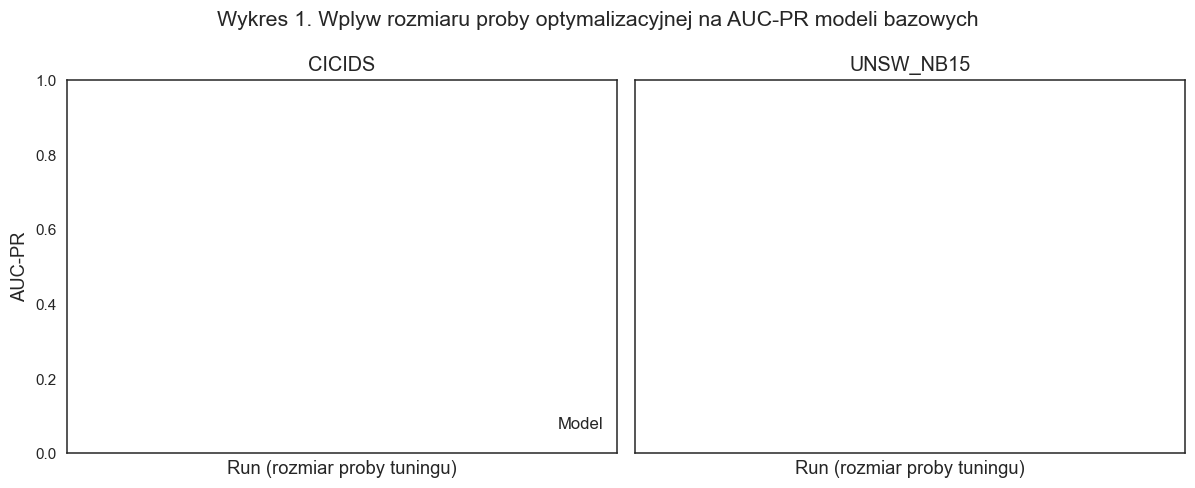

In [3]:
single_df = df_std[df_std["model_type"].isin(SINGLE_MODELS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, dset in zip(axes, ["CICIDS", "UNSW_NB15"]):
    sub = single_df[single_df["dataset_name"] == dset]
    piv = sub.groupby(["model_type", "run_index"])["AUC_PR"].mean().reset_index()
    for i, model in enumerate(SINGLE_MODELS):
        line = piv[piv["model_type"] == model].sort_values("run_index")
        if line.empty:
            continue
        ax.plot(line["run_index"], line["AUC_PR"], marker=MARKERS[i % len(MARKERS)],
                linestyle=LINESTYLES[i % len(LINESTYLES)], color=GRAYS[i % len(GRAYS)],
                label=model, markersize=7, linewidth=1.6)
    ax.set_title(dset)
    ax.set_xlabel("Run (rozmiar proby tuningu)")
    ax.set_xticks(sorted(single_df["run_index"].dropna().unique()))
axes[0].set_ylabel("AUC-PR")
axes[0].legend(title="Model", loc="lower right")
fig.suptitle("Wykres 1. Wplyw rozmiaru proby optymalizacyjnej na AUC-PR modeli bazowych")
fig.tight_layout()
save_fig(fig, "fig1_run_size_vs_aucpr_baselines")
plt.show()

In [4]:
table1 = (single_df.groupby(["dataset_name", "model_type", "run_index"])[["AUC_ROC", "AUC_PR", "F1"]]
          .mean().reset_index()
          .sort_values(["dataset_name", "model_type", "run_index"]))

display(table1.style.format({"AUC_ROC": "{:.3f}", "AUC_PR": "{:.3f}", "F1": "{:.3f}"})
        .set_caption("Tabela 1. Metryki modeli bazowych w zaleznosci od rozmiaru proby tuningu (Run 1-3)"))

table1.to_csv(FIG_DIR / "table1_baselines_by_run.csv", index=False)
table1_latex = table1.rename(columns={"dataset_name": "Dataset", "model_type": "Model", "run_index": "Run"})
with open(FIG_DIR / "table1_baselines_by_run.tex", "w", encoding="utf-8") as f:
    f.write(table1_latex.to_latex(
        index=False, float_format="%.3f",
        caption="Wplyw rozmiaru proby optymalizacyjnej na metryki modeli bazowych.",
        label="tab:baselines_by_run"
    ))
print("Zapisano table1_baselines_by_run.tex")

,dataset_name,model_type,run_index,AUC_ROC,AUC_PR,F1


Zapisano table1_baselines_by_run.tex


## SEKCJA 2: Modele Bazowe vs Zespoly (Ogolna Skutecznosc)

**Wykres 2** — rozklad AUC-PR (z 3 runow x roznych konfiguracji) w dwoch kategoriach:
Single Models vs Ensembles, z podzialem kolorystycznym na dataset.

Zapisano: fig2_single_vs_ensemble_boxplot.pdf , fig2_single_vs_ensemble_boxplot.png


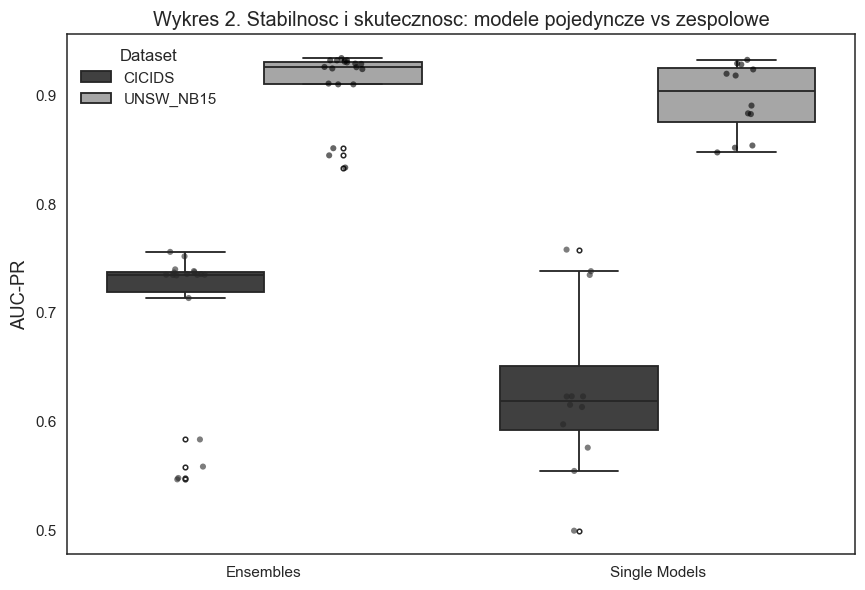

In [5]:
df_std["model_category"] = df_std["model_type"].apply(categorize)
cat_df = df_std.dropna(subset=["model_category"])

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=cat_df, x="model_category", y="AUC_PR", hue="dataset_name",
            palette={"CICIDS": "#404040", "UNSW_NB15": "#A6A6A6"}, ax=ax,
            linewidth=1.2, fliersize=3)
sns.stripplot(data=cat_df, x="model_category", y="AUC_PR", hue="dataset_name",
              dodge=True, palette="dark:black", size=4, alpha=0.6, ax=ax, legend=False)
ax.set_xlabel("")
ax.set_ylabel("AUC-PR")
ax.set_title("Wykres 2. Stabilnosc i skutecznosc: modele pojedyncze vs zespolowe")
ax.legend(title="Dataset")
fig.tight_layout()
save_fig(fig, "fig2_single_vs_ensemble_boxplot")
plt.show()

In [6]:
key_families = SINGLE_MODELS + ENSEMBLE_MODELS
fam_df = df_std[df_std["model_type"].isin(key_families)]

table2 = fam_df.groupby(["dataset_name", "model_type"])[["AUC_ROC", "AUC_PR", "F1", "Precision"]].agg(["mean", "std"])
table2.columns = [f"{m}_{s}" for m, s in table2.columns]
table2 = table2.reset_index().sort_values(["dataset_name", "model_type"])

display(table2.style.format({c: "{:.3f}" for c in table2.columns if c not in ["dataset_name", "model_type"]})
        .set_caption("Tabela 2. Srednia +/- odchylenie std. (wszystkie runy/strategie) dla kluczowych rodzin modeli"))

table2.to_csv(FIG_DIR / "table2_family_mean_std.csv", index=False)
with open(FIG_DIR / "table2_family_mean_std.tex", "w", encoding="utf-8") as f:
    f.write(table2.to_latex(
        index=False, float_format="%.3f",
        caption="Srednia i odchylenie standardowe metryk dla kluczowych rodzin modeli.",
        label="tab:family_mean_std"
    ))

def combine_mean_std(t, metrics):
    out = t[["dataset_name", "model_type"]].copy()
    for m in metrics:
        out[m] = t[f"{m}_mean"].map("{:.3f}".format) + " +/- " + t[f"{m}_std"].map("{:.3f}".format)
    return out

table2_pretty = combine_mean_std(table2, ["AUC_ROC", "AUC_PR", "F1", "Precision"])
display(table2_pretty.style.set_caption("Tabela 2 (wersja do pracy) - mean +/- std"))
table2_pretty.to_csv(FIG_DIR / "table2_family_mean_std_pretty.csv", index=False)
print("Zapisano table2_family_mean_std.tex")

,dataset_name,model_type,AUC_ROC_mean,AUC_ROC_std,AUC_PR_mean,AUC_PR_std,F1_mean,F1_std,Precision_mean,Precision_std
0,CICIDS,Ensemble_with_LUNAR,0.887,0.002,0.747,0.011,0.703,0.008,0.666,0.020
1,CICIDS,Ensemble_without_LUNAR,0.882,0.002,0.730,0.015,0.722,0.003,0.710,0.020
2,CICIDS,IsolationForest,0.819,0.009,0.608,0.010,0.551,0.016,0.712,0.200
3,CICIDS,LOF,0.848,0.008,0.543,0.039,0.662,0.026,0.583,0.005
4,CICIDS,LUNAR,0.869,0.004,0.743,0.013,0.678,0.010,0.670,0.020
5,CICIDS,LUNAR_Self_Ensemble,0.827,0.074,0.676,0.087,0.667,0.021,0.677,0.062
6,CICIDS,OneClassSVM,0.768,0.001,0.623,0.000,0.391,0.000,0.243,0.000
7,UNSW_NB15,Ensemble_with_LUNAR,0.892,0.001,0.924,0.001,0.818,0.004,0.810,0.013
8,UNSW_NB15,Ensemble_without_LUNAR,0.875,0.001,0.910,0.000,0.806,0.004,0.834,0.008
9,UNSW_NB15,IsolationForest,0.845,0.001,0.885,0.004,0.797,0.004,0.781,0.005


,dataset_name,model_type,AUC_ROC,AUC_PR,F1,Precision
0,CICIDS,Ensemble_with_LUNAR,0.887 +/- 0.002,0.747 +/- 0.011,0.703 +/- 0.008,0.666 +/- 0.020
1,CICIDS,Ensemble_without_LUNAR,0.882 +/- 0.002,0.730 +/- 0.015,0.722 +/- 0.003,0.710 +/- 0.020
2,CICIDS,IsolationForest,0.819 +/- 0.009,0.608 +/- 0.010,0.551 +/- 0.016,0.712 +/- 0.200
3,CICIDS,LOF,0.848 +/- 0.008,0.543 +/- 0.039,0.662 +/- 0.026,0.583 +/- 0.005
4,CICIDS,LUNAR,0.869 +/- 0.004,0.743 +/- 0.013,0.678 +/- 0.010,0.670 +/- 0.020
5,CICIDS,LUNAR_Self_Ensemble,0.827 +/- 0.074,0.676 +/- 0.087,0.667 +/- 0.021,0.677 +/- 0.062
6,CICIDS,OneClassSVM,0.768 +/- 0.001,0.623 +/- 0.000,0.391 +/- 0.000,0.243 +/- 0.000
7,UNSW_NB15,Ensemble_with_LUNAR,0.892 +/- 0.001,0.924 +/- 0.001,0.818 +/- 0.004,0.810 +/- 0.013
8,UNSW_NB15,Ensemble_without_LUNAR,0.875 +/- 0.001,0.910 +/- 0.000,0.806 +/- 0.004,0.834 +/- 0.008
9,UNSW_NB15,IsolationForest,0.845 +/- 0.001,0.885 +/- 0.004,0.797 +/- 0.004,0.781 +/- 0.005


Zapisano table2_family_mean_std.tex


## SEKCJA 3: Rola LUNAR w Zespolach (Wartosc Dodana)

**Wykres 3** — delta metryk (F1, AUC-PR) pomiedzy `Ensemble_with_LUNAR` a `Ensemble_without_LUNAR`
dla tych samych strategii fuzji i tego samego run_index (par dopasowanych 1:1).

**Wykres 4** — heatmapa: srednie AUC-PR wg strategii fuzji (z udzialem LUNAR) x dataset.

Zapisano: fig3_lunar_added_value_delta.pdf , fig3_lunar_added_value_delta.png


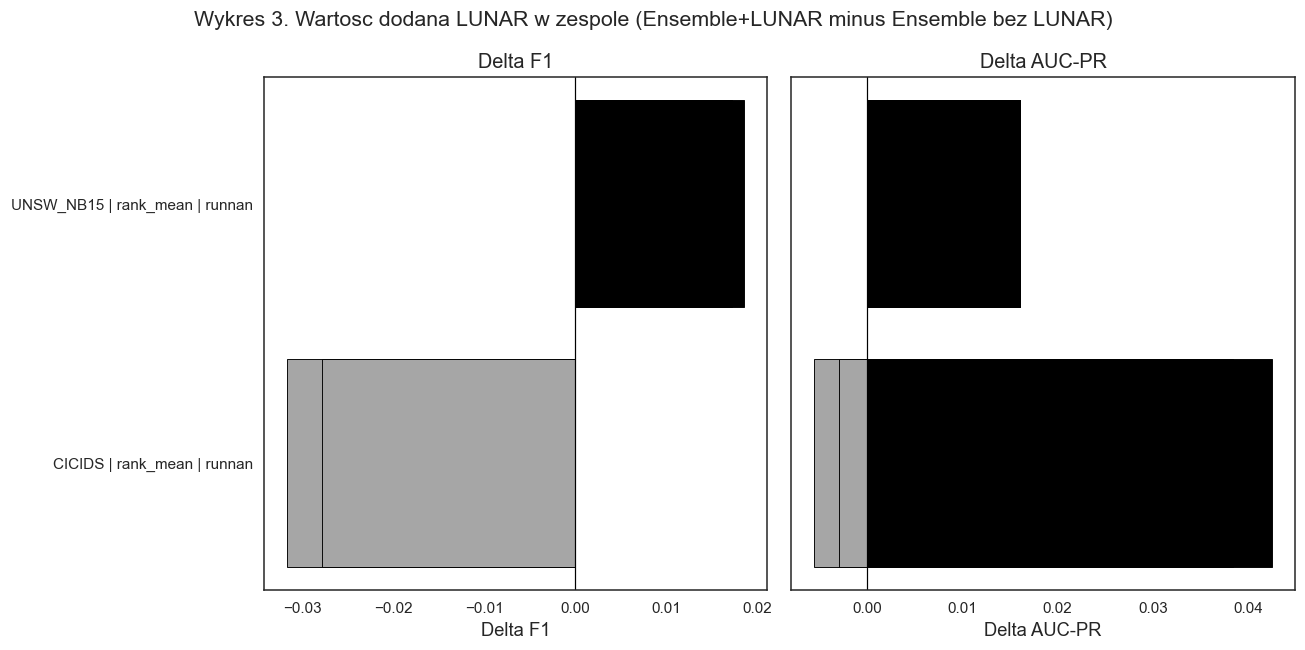

In [7]:
cols_needed = ["dataset_name", "fusion_strategy", "run_index", "F1", "AUC_PR", "runtime_train"]
with_df = df_std[df_std["model_type"] == "Ensemble_with_LUNAR"][cols_needed]
without_df = df_std[df_std["model_type"] == "Ensemble_without_LUNAR"][cols_needed]

merged = with_df.merge(without_df, on=["dataset_name", "fusion_strategy", "run_index"],
                       suffixes=("_with", "_without"))
merged["delta_F1"] = merged["F1_with"] - merged["F1_without"]
merged["delta_AUC_PR"] = merged["AUC_PR_with"] - merged["AUC_PR_without"]
merged["delta_runtime_train"] = merged["runtime_train_with"] - merged["runtime_train_without"]
merged["label"] = (merged["dataset_name"] + " | " + merged["fusion_strategy"].astype(str)
                    + " | run" + merged["run_index"].astype(str))

if merged.empty:
    print("UWAGA: brak par Ensemble_with/without_LUNAR z ta sama strategia fuzji i run_index. "
          "Sprawdz, czy obie rodziny mają wspolne fusion_strategy (np. tylko 'rank_mean').")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, max(4, 0.4 * len(merged))), sharey=True)
    for ax, metric, title in zip(axes, ["delta_F1", "delta_AUC_PR"], ["Delta F1", "Delta AUC-PR"]):
        colors = ["#000000" if v >= 0 else "#A6A6A6" for v in merged[metric]]
        ax.barh(merged["label"], merged[metric], color=colors, edgecolor="black", linewidth=0.6)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(title)
        ax.set_xlabel(title)
    fig.suptitle("Wykres 3. Wartosc dodana LUNAR w zespole (Ensemble+LUNAR minus Ensemble bez LUNAR)")
    fig.tight_layout()
    save_fig(fig, "fig3_lunar_added_value_delta")
    plt.show()

Zapisano: fig4_fusion_strategy_heatmap.pdf , fig4_fusion_strategy_heatmap.png


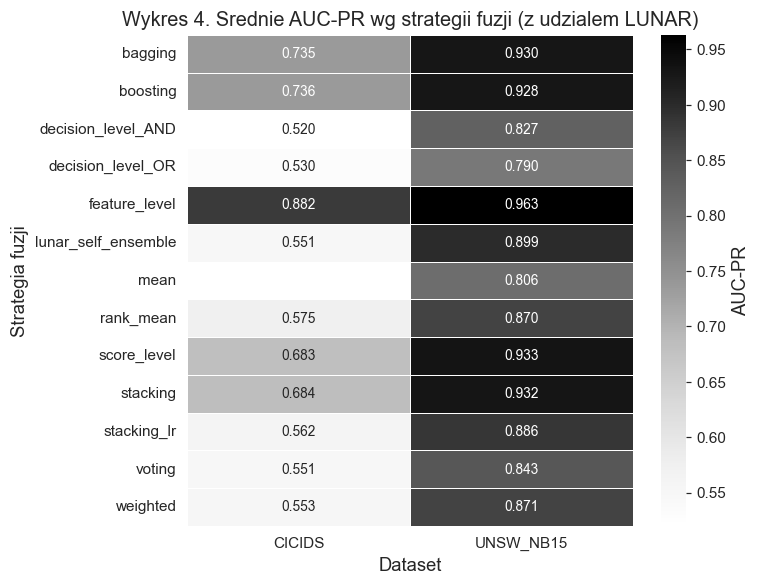

In [8]:
fusion_model_types = ["Ensemble_with_LUNAR", "Fusion_Level_Comparison", "LUNAR_Self_Ensemble"]
if "LUNAR_Fusion_v2" in df_std["model_type"].unique():
    fusion_model_types.append("LUNAR_Fusion_v2")

fusion_df = df_std[df_std["model_type"].isin(fusion_model_types)].dropna(subset=["fusion_strategy"])
heat = fusion_df.groupby(["fusion_strategy", "dataset_name"])["AUC_PR"].mean().unstack("dataset_name")

fig, ax = plt.subplots(figsize=(7, max(4, 0.42 * len(heat))))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="Greys", cbar_kws={"label": "AUC-PR"}, ax=ax,
            linewidths=0.5, linecolor="white", annot_kws={"size": 9})
ax.set_title("Wykres 4. Srednie AUC-PR wg strategii fuzji (z udzialem LUNAR)")
ax.set_ylabel("Strategia fuzji")
ax.set_xlabel("Dataset")
fig.tight_layout()
save_fig(fig, "fig4_fusion_strategy_heatmap")
plt.show()

## SEKCJA 4: Kompromis (Skutecznosc a Zlozonosc Czasowa)

**Wykres 5** — koszt wnioskowania (log) vs AUC-PR, ksztalt = dataset, kolor = single vs ensemble.

**Wykres 6** — koszt treningu (tuning + fit, log) vs AUC-PR, z liniami pokazujacymi
progresje run 1 -> 3 dla tego samego modelu (jak skaluje sie koszt ze wzrostem proby tuningu).

Zapisano: fig5_cost_inference_vs_aucpr.pdf , fig5_cost_inference_vs_aucpr.png


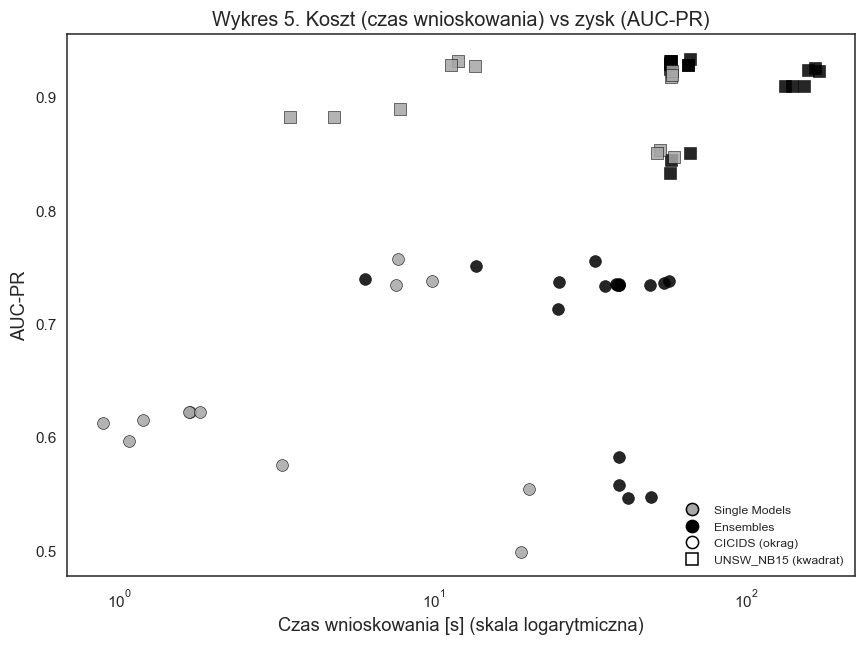

In [9]:
plot_df = df_std[df_std["model_type"].isin(SINGLE_MODELS + ENSEMBLE_MODELS)].copy()
plot_df["category"] = plot_df["model_type"].apply(categorize)

markers_ds = {"CICIDS": "o", "UNSW_NB15": "s"}
colors_cat = {"Single Models": "#A6A6A6", "Ensembles": "#000000"}

legend_handles = [
    mlines.Line2D([0], [0], marker="o", color="w", markerfacecolor="#A6A6A6",
                  markeredgecolor="black", markersize=8, label="Single Models"),
    mlines.Line2D([0], [0], marker="o", color="w", markerfacecolor="#000000",
                  markeredgecolor="black", markersize=8, label="Ensembles"),
    mlines.Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
                  markeredgecolor="black", markersize=8, label="CICIDS (okrag)"),
    mlines.Line2D([0], [0], marker="s", color="w", markerfacecolor="white",
                  markeredgecolor="black", markersize=8, label="UNSW_NB15 (kwadrat)"),
]

fig, ax = plt.subplots(figsize=(8, 6))
for (cat, dset), g in plot_df.groupby(["category", "dataset_name"]):
    ax.scatter(g["runtime_inference"], g["AUC_PR"], marker=markers_ds.get(dset, "x"),
               color=colors_cat.get(cat, "gray"), s=60, edgecolor="black", linewidth=0.4, alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("Czas wnioskowania [s] (skala logarytmiczna)")
ax.set_ylabel("AUC-PR")
ax.set_title("Wykres 5. Koszt (czas wnioskowania) vs zysk (AUC-PR)")
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)
fig.tight_layout()
save_fig(fig, "fig5_cost_inference_vs_aucpr")
plt.show()

Zapisano: fig6_cost_training_vs_aucpr.pdf , fig6_cost_training_vs_aucpr.png


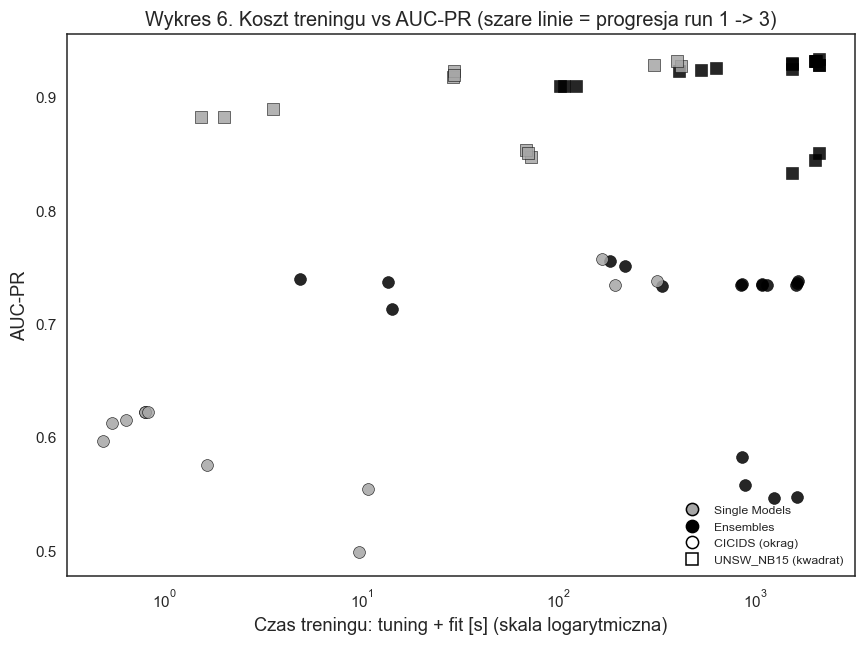

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for (cat, dset), g in plot_df.groupby(["category", "dataset_name"]):
    ax.scatter(g["runtime_train"], g["AUC_PR"], marker=markers_ds.get(dset, "x"),
               color=colors_cat.get(cat, "gray"), s=60, edgecolor="black", linewidth=0.4, alpha=0.85)

for (model, dset), g in plot_df.groupby(["model_type", "dataset_name"]):
    g = g.sort_values("run_index")
    if g["run_index"].nunique() > 1:
        ax.plot(g["runtime_train"], g["AUC_PR"], color="black", alpha=0.25, linewidth=0.8, zorder=0)

ax.set_xscale("log")
ax.set_xlabel("Czas treningu: tuning + fit [s] (skala logarytmiczna)")
ax.set_ylabel("AUC-PR")
ax.set_title("Wykres 6. Koszt treningu vs AUC-PR (szare linie = progresja run 1 -> 3)")
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)
fig.tight_layout()
save_fig(fig, "fig6_cost_training_vs_aucpr")
plt.show()

## SEKCJA 5: Analiza Krzywych (Jakosc Detekcji w Pelnym Spektrum)

**Wykres 7** — krzywe Precision-Recall dla CICIDS: najlepszy klasyczny baseline (wg AUC-PR),
najlepszy pojedynczy LUNAR, najlepszy zespol z LUNAR. Krzywe pobrane z kolumny `pr_curve_json`.

Brak pr_curve_json dla OneClassSVM / CICIDS - pominieto.
Zapisano: fig7_pr_curves_cicids.pdf , fig7_pr_curves_cicids.png


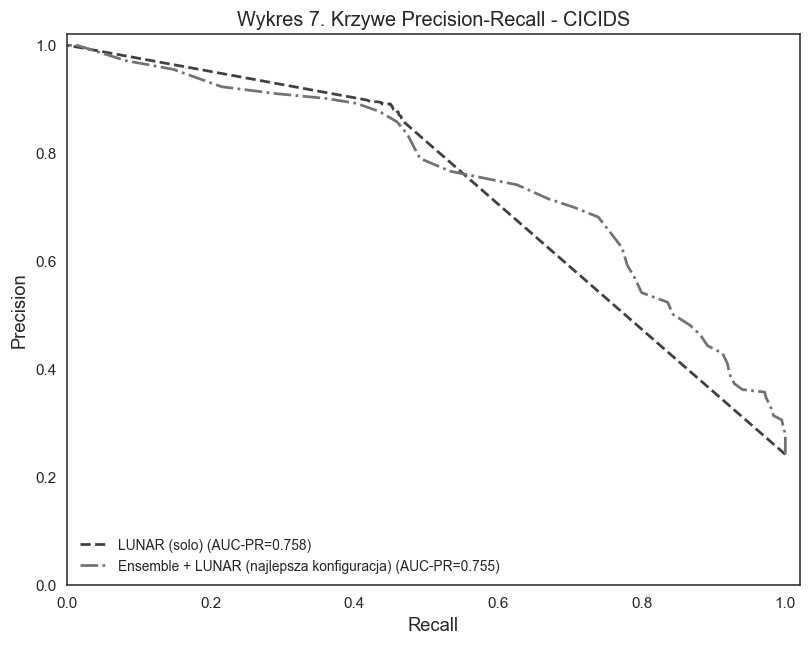

In [11]:
def best_pr_curve(df, model_type, dataset, fusion_strategy=None):
    sub = df[(df["model_type"] == model_type) & (df["dataset_name"] == dataset)]
    if fusion_strategy is not None:
        sub = sub[sub["fusion_strategy"] == fusion_strategy]
    sub = sub.dropna(subset=["pr_curve_json"])
    if sub.empty:
        return None, None
    best = sub.loc[sub["AUC_PR"].idxmax()]
    curve = pd.DataFrame(json.loads(best["pr_curve_json"]))
    return curve, best["AUC_PR"]

baseline_candidates = df_std[(df_std["dataset_name"] == "CICIDS") &
                              (df_std["model_type"].isin(["LOF", "IsolationForest", "OneClassSVM"]))]
best_baseline_model = (baseline_candidates.loc[baseline_candidates["AUC_PR"].idxmax(), "model_type"]
                        if not baseline_candidates.empty else None)

curves_to_plot = [
    (f"{best_baseline_model} (najlepszy klasyczny baseline)", best_baseline_model, None),
    ("LUNAR (solo)", "LUNAR", None),
    ("Ensemble + LUNAR (najlepsza konfiguracja)", "Ensemble_with_LUNAR", None),
]

fig, ax = plt.subplots(figsize=(7.5, 6))
styles = [("-", "#000000"), ("--", "#404040"), ("-.", "#737373")]
for (label, mtype, fstrat), (ls, color) in zip(curves_to_plot, styles):
    if mtype is None:
        continue
    curve, aucpr = best_pr_curve(df_std, mtype, "CICIDS", fstrat)
    if curve is None:
        print(f"Brak pr_curve_json dla {mtype} / CICIDS - pominieto.")
        continue
    ax.plot(curve["recall"], curve["precision"], linestyle=ls, color=color, linewidth=1.8,
            label=f"{label} (AUC-PR={aucpr:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.set_title("Wykres 7. Krzywe Precision-Recall - CICIDS")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
save_fig(fig, "fig7_pr_curves_cicids")
plt.show()

## SEKCJA 6: Propozycje wlasne (na bazie doswiadczenia i wczesniejszej analizy)

Poza siedmioma zamowionymi wykresami, warto dodac do pracy:

1. **Test istotnosci statystycznej** (nizej) — parowany test t i test Wilcoxona na roznicach
   F1 miedzy Ensemble_with_LUNAR i Ensemble_without_LUNAR (te same 3 runy x strategie fuzji).
   Samo "delta > 0" na Wykresie 3 nie mowi, czy roznica jest istotna statystycznie — przy tak
   malej liczbie powtorzen (3 runy) recenzent/promotor prawie na pewno o to zapyta.
2. **Wskaznik cost-benefit** (nizej) — ΔAUC-PR / Δczas_treningu w sekundach: liczba wyrazajaca
   "ile AUC-PR zyskujemy na kazda dodatkowa sekunde treningu" przy dodaniu LUNAR do zespolu.
   Jedna liczba w tabeli koncowej jest czesto bardziej przekonujaca dla recenzenta niz sam wykres.
3. **Krzywe PR dla UNSW_NB15 analogicznie do Wykresu 7** (mala zmiana `dataset_name="CICIDS"` na
   `"UNSW_NB15"` w komorce Wykresu 7) — pokazuje, czy hierarchia baseline < LUNAR < Ensemble+LUNAR
   jest uniwersalna czy specyficzna dla jednego zbioru.
4. **Wykres "generalization gap"** (F1 na CICIDS vs UNSW dla tej samej rodziny modelu) — juz
   przygotowany we wczesniejszej wersji notebooka (`02b_dataset_degradation`), warto go dolaczyc
   jako uzupelnienie Sekcji 2, bo wprost pokazuje ktore modele sa najbardziej "przetrenowane" pod
   jeden dataset.

In [12]:
# --- Test istotnosci: czy dodanie LUNAR do zespolu istotnie zmienia F1? ---
if not merged.empty and len(merged) >= 2:
    t_stat, p_val = stats.ttest_rel(merged["F1_with"], merged["F1_without"])
    try:
        w_stat, w_p = stats.wilcoxon(merged["F1_with"], merged["F1_without"])
    except ValueError:
        w_stat, w_p = np.nan, np.nan

    print(f"Parowany test t (F1, with vs without LUNAR): t = {t_stat:.3f}, p = {p_val:.4f}")
    if not np.isnan(w_p):
        print(f"Test Wilcoxona (F1, with vs without LUNAR): W = {w_stat:.3f}, p = {w_p:.4f}")
    else:
        print("Test Wilcoxona: niewystarczajaca liczba par (lub same zera roznic).")

    if p_val < 0.05:
        print(">>> Roznica F1 jest istotna statystycznie na poziomie alfa = 0.05.")
    else:
        print(">>> Roznica F1 NIE jest istotna statystycznie na poziomie alfa = 0.05 "
              "(prawdopodobnie ze wzgledu na mala liczbe par - n=%d)." % len(merged))
else:
    print("Za malo sparowanych obserwacji (potrzeba >= 2 par o tej samej strategii i run_index).")

Parowany test t (F1, with vs without LUNAR): t = -1.269, p = 0.2251
Test Wilcoxona (F1, with vs without LUNAR): W = 38.000, p = 0.2293
>>> Roznica F1 NIE jest istotna statystycznie na poziomie alfa = 0.05 (prawdopodobnie ze wzgledu na mala liczbe par - n=15).


In [13]:
# --- Wskaznik cost-benefit: przyrost AUC-PR na dodatkowa sekunde czasu treningu ---
if not merged.empty:
    merged["cost_benefit_ratio"] = merged["delta_AUC_PR"] / merged["delta_runtime_train"].replace(0, np.nan)
    cb_table = merged[["dataset_name", "fusion_strategy", "run_index",
                        "delta_AUC_PR", "delta_runtime_train", "cost_benefit_ratio"]] \
        .sort_values("cost_benefit_ratio", ascending=False)

    display(cb_table.style.format({
        "delta_AUC_PR": "{:.4f}", "delta_runtime_train": "{:.1f}", "cost_benefit_ratio": "{:.6f}"
    }).set_caption("Wskaznik cost-benefit: delta AUC-PR na dodatkowa sekunde czasu treningu "
                    "(dodanie LUNAR do zespolu)"))
    cb_table.to_csv(FIG_DIR / "table_cost_benefit_lunar.csv", index=False)
else:
    print("Brak danych do wyliczenia wskaznika cost-benefit.")

,dataset_name,fusion_strategy,run_index,delta_AUC_PR,delta_runtime_train,cost_benefit_ratio
5,CICIDS,rank_mean,nan,0.0425,167.3,0.000254
2,CICIDS,rank_mean,nan,0.0384,203.2,0.000189
4,CICIDS,rank_mean,nan,0.0187,167.8,0.000111
3,CICIDS,rank_mean,nan,0.0161,176.6,0.000091
1,CICIDS,rank_mean,nan,0.0146,203.7,0.000072
11,CICIDS,rank_mean,nan,0.0208,320.2,0.000065
0,CICIDS,rank_mean,nan,0.0120,212.5,0.000056
13,UNSW_NB15,rank_mean,nan,0.0140,286.6,0.000049
12,UNSW_NB15,rank_mean,nan,0.0140,302.5,0.000046
14,UNSW_NB15,rank_mean,nan,0.0133,307.2,0.000043
